# 1. Modellistica QUBO

## Variabili decisionali

Sia $\mathcal{P} = \{p_1,\dots,p_N\}, \qquad p_i=(x_i,y_i)$ l'insieme delle posizioni candidate ottenute discretizzando le cinque regioni ammissibili del Case Study 4 dell'IEA Wind Task 37.

Le candidate locations sono parametri fissi del problema.

Per ogni posizione candidata introduciamo una variabile binaria

$z_i =
\begin{cases}
1 & \text{se viene installata una turbina nella posizione } p_i,\\
0 & \text{altrimenti.}
\end{cases}$

Pertanto, 
$\mathbf z=(z_1,\dots,z_N)^T \in \{0,1\}^N.$

L'obiettivo è formulare il problema di Wind Farm Layout Optimization come $\min_{\mathbf z} \mathbf z^T Q \mathbf z.$

---

## Modello di produzione energetica

Sia $A_0$ l'Annual Energy Production di una singola turbina isolata,
calcolata utilizzando il modello fisico ufficiale del benchmark.

Per ogni coppia di posizioni candidate $p_i,p_j$, calcoliamo l'AEP di
una wind farm composta dalle sole due turbine:

$AEP_{ij} = AEP(\{p_i,p_j\}).$

Definiamo quindi la perdita energetica pairwise dovuta al wake effect come

$L_{ij}=2A_0-AEP_{ij}.$

Il termine $L_{ij}\geq0$ rappresenta quindi la perdita annua di energia
causata dall'interazione aerodinamica tra le turbine poste nelle
posizioni $p_i$ e $p_j$.

Possiamo quindi definire una approssimazione quadratica dell'AEP come

$\widetilde{AEP}(\mathbf z)=A_0\sum_i z_i-\sum_{i<j}L_{ij}z_i z_j.$

Poiché un problema QUBO viene formulato come problema di minimizzazione,
possiamo equivalentemente minimizzare il negativo dell'AEP approssimata:

$H_{\mathrm{AEP}}(\mathbf z)=-A_0\sum_i z_i+\sum_{i<j}L_{ij}z_i z_j.$

I coefficienti $L_{ij}$ vengono ottenuti utilizzando direttamente
il modello fisico ufficiale del benchmark, basato sul
Simplified Bastankhah Gaussian wake model.

È importante osservare che questa formulazione costituisce una
approssimazione quadratica del modello fisico completo.

Nel caso di più turbine, infatti, il modello ufficiale combina in modo
non lineare i wake deficit prodotti da più turbine upstream. In generale,

$\widetilde{AEP}(\mathbf z)\neq AEP_{\mathrm{official}}(\mathbf z).$

Per questo motivo il layout finale prodotto dal QUBO dovrà essere
successivamente rivalutato mediante il modello AEP ufficiale completo.

---

## Vincolo 1: numero di turbine

Il Case Study 4 richiede esattamente 81 turbine:

$\sum_i z_i = 81.$

Questo vincolo viene inserito nella funzione obiettivo mediante il termine
di penalità

$H_N(\mathbf z)=\lambda_N \left(\sum_i z_i - 81\right)^2.$

Il termine assume valore minimo quando vengono selezionate esattamente
81 candidate locations.

---

## Vincolo 2: distanza minima tra turbine

Il diametro del rotore della turbina di riferimento è

$D=198\text{ m}.$

Il benchmark richiede una distanza minima tra due turbine pari a

$d_{\min}=2D=396\text{ m}.$

Definiamo quindi l'insieme delle coppie di posizioni incompatibili

$\mathcal E_{\mathrm{invalid}}=\left\{(i,j):\|p_i-p_j\|<396\right\}.
$

Per ciascuna coppia non ammissibile viene introdotta una penalità:

$H_S(\mathbf z)=\lambda_S \sum_{(i,j)\in\mathcal E_{\mathrm{invalid}}}z_i z_j. $

Se entrambe le variabili $z_i$ e $z_j$ assumono valore 1, il termine
di penalità viene attivato.

---

## Vincolo sulle boundary

Non è necessario introdurre un ulteriore termine QUBO per imporre le
boundary della wind farm.

Le candidate locations esterne alle cinque regioni ammissibili sono già
state eliminate durante la fase di discretizzazione mediante la
costruzione di `candidate_locations`.

Di conseguenza, ogni variabile binaria $z_i$ corrisponde già a una
posizione geograficamente valida.

---

## Funzione QUBO completa

La funzione obiettivo complessiva è quindi

$ \boxed{H(\mathbf z)=-A_0\sum_i z_i+\sum_{i<j}L_{ij}z_i z_j+\lambda_S \sum_{(i,j)\in\mathcal E_{\mathrm{invalid}}}z_i z_j + \lambda_N \left( \sum_i z_i-81 \right)^2 }
$

e il problema di ottimizzazione diventa

$\boxed{ \mathbf z^* = \operatorname*{argmin}_{\mathbf z\in\{0,1\}^N} \mathbf z^TQ\mathbf z }$

a meno di un termine costante introdotto dall'espansione del vincolo di
cardinalità.

Poiché tutti i layout ammissibili contengono esattamente 81 turbine,

$-A_0\sum_i z_i=-81A_0$

è costante nello spazio delle soluzioni ammissibili.

Di conseguenza, il termine lineare associato alla produzione di una
singola turbina potrebbe essere rimosso senza modificare il layout
ottimo tra le soluzioni ammissibili.

La parte realmente discriminante della funzione obiettivo diventa quindi

$\sum_{i<j}L_{ij}z_i z_j,$

ossia la minimizzazione delle perdite energetiche dovute al wake effect,
soggetta ai vincoli sul numero di turbine e sulla distanza minima.

---

## Valutazione finale

Il valore della funzione QUBO non coincide direttamente con l'AEP
ufficiale del benchmark.

La pipeline completa è quindi:

$\text{candidate locations}\rightarrow \text{QUBO} \rightarrow \text{solver} \rightarrow \text{layout di 81 turbine} \rightarrow \text{modello AEP ufficiale} \rightarrow AEP_{\mathrm{official}}. $

Il valore $AEP_{\mathrm{official}}$ ottenuto nell'ultimo passaggio è
quello che dovrà essere utilizzato per confrontare il metodo QUBO con gli
otto algoritmi riportati nel paper.

# 2. Codice

In [1]:
# import yaml
# import matplotlib.pyplot as plt

# from shapely.geometry import Polygon
import sys
from pathlib import Path
from shapely.ops import unary_union
# import shapely
import numpy as np
from shapely.geometry.multipolygon import MultiPolygon

sys.path.append("..")
from src.qubo_windfarm_layout.model import get_farm_area, get_mask

sys.path.append("../external/thomas-wflo-benchmark/src/physics-models")

from provided_model import (
    calcAEPcs3,
    getWindRoseYAML,
    getTurbAtrbtYAML,

)

ROOT = Path.cwd()

# se il notebook viene eseguito dalla cartella notebooks/
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

BENCHMARK_ROOT = ROOT / "external" / "thomas-wflo-benchmark"

BOUNDARY_FILE = (
    BENCHMARK_ROOT
    / "src"
    / "input-files"
    / "farms"
    / "iea37-boundary-cs4.yaml"
)

WIND_FILE = (
    BENCHMARK_ROOT
    / "src"
    / "input-files"
    / "wind"
    / "iea37-windrose-cs4.yaml"
)

TURBINE_FILE = (
    BENCHMARK_ROOT
    / "src"
    / "input-files"
    / "turbines"
    / "iea37-10mw.yaml"
)


## 2.1 Get Candidates Points

In [2]:
# Get candidates
polygons, farm_area = get_farm_area()
X, Y, mask = get_mask(farm_area=farm_area, grid_resolution=1000)

candidate_locations = np.column_stack([
    X[mask],
    Y[mask],
])

print(f"Filtered candidates shape {candidate_locations.shape}")

candidate_map = {
    i: tuple(coord)
    for i, coord in enumerate(candidate_locations)
}

Filtered candidates shape (34, 2)


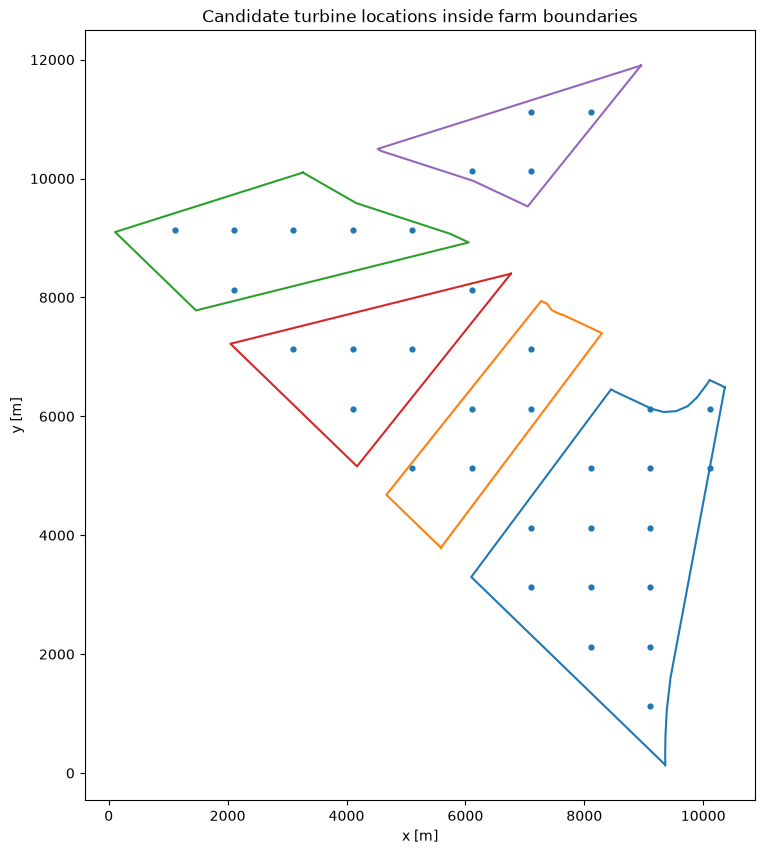

In [3]:
# Visualization
import matplotlib.pyplot as plt

xs = [coord[0] for coord in candidate_map.values()]
ys = [coord[1] for coord in candidate_map.values()]

fig, ax = plt.subplots(figsize=(10, 10))

# Candidate locations
ax.scatter(xs, ys, s=12)

# Boundary polygons
for polygon in polygons:
    bx, by = polygon.exterior.xy
    ax.plot(bx, by)

ax.set_aspect("equal")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title("Candidate turbine locations inside farm boundaries")

plt.show()

In [4]:
# Distance constraint
from scipy.spatial.distance import cdist

distances = cdist(
    candidate_locations,
    candidate_locations
)

MIN_DISTANCE = 396  # 2 * 198 m

invalid_pairs = np.argwhere(
    (distances < MIN_DISTANCE)
    & (distances > 0)
)

invalid_pairs = np.argwhere(
    np.triu(
        (distances < MIN_DISTANCE)
        & (distances > 0),
        k=1
    )
)

## 2.2 QUBO Matrix

In [5]:
wind_dir, wind_dir_freq, wind_speeds, wind_speed_probs, *_ = (
    getWindRoseYAML(WIND_FILE)
)

turb_ci, turb_co, rated_ws, rated_pwr, turb_diam = (
    getTurbAtrbtYAML(TURBINE_FILE)
)

def _compute_aep_from_coords(coords):
    aep_by_direction = calcAEPcs3(
        turb_coords=np.asarray(coords),
        wind_freq=wind_dir_freq,
        wind_speeds=wind_speeds,
        wind_speed_probs=wind_speed_probs,
        wind_dir=wind_dir,
        turb_diam=turb_diam,
        turb_ci=turb_ci,
        turb_co=turb_co,
        rated_ws=rated_ws,
        rated_pwr=rated_pwr,
    )

    return np.sum(aep_by_direction)


In [6]:
def build_qubo_matrix(
    candidate_locations,
    invalid_pairs,
    n_turbines=81,
    lambda_cardinality=1e6,
    lambda_spacing=1e6,
    include_single_turbine_term=False,
):
    """
    Costruisce la matrice Q simmetrica tale che:

        H(z) = z.T @ Q @ z + offset

    dove z_i = 1 se una turbina viene posizionata
    nella candidate location i.

    Il modello include:
        - produzione energetica della singola turbina
        - wake loss pairwise
        - vincolo sul numero esatto di turbine
        - vincolo sulla distanza minima

    Parameters
    ----------
    candidate_locations : array-like, shape (N, 2)
        Coordinate candidate (x, y).

    invalid_pairs : array-like, shape (M, 2)
        Coppie (i, j) che violano la distanza minima.

    _compute_aep_from_coords : callable
        Funzione che prende coordinate shape (n_turbines, 2)
        e restituisce l'AEP totale.

    n_turbines : int
        Numero esatto di turbine da selezionare.

    lambda_cardinality : float
        Penalità per il vincolo sul numero di turbine.

    lambda_spacing : float
        Penalità per il vincolo di distanza minima.

    include_single_turbine_term : bool
        Se True include il termine -A0 * sum(z_i).
        Poiché il numero di turbine è fissato, questo termine
        può anche essere omesso.

    Returns
    -------
    Q : np.ndarray
        Matrice QUBO simmetrica.

    offset : float
        Termine costante della funzione QUBO.

    A0 : float
        AEP di una singola turbina isolata.

    wake_loss_matrix : np.ndarray
        Matrice L con le wake loss pairwise.
    """

    candidate_locations = np.asarray(
        candidate_locations,
        dtype=float,
    )

    n_candidates = len(candidate_locations)

    # --------------------------------------------------
    # 1. AEP della singola turbina isolata
    # --------------------------------------------------

    A0 = _compute_aep_from_coords(
        [candidate_locations[0]]
    )

    print(f"AEP singola turbina: {A0:.6f}")

    # --------------------------------------------------
    # 2. Wake loss pairwise
    #
    # L_ij = 2*A0 - AEP(i,j)
    # --------------------------------------------------

    wake_loss_matrix = np.zeros(
        (n_candidates, n_candidates),
        dtype=float,
    )

    for i in range(n_candidates):

        for j in range(i + 1, n_candidates):

            pair_coords = np.array([
                candidate_locations[i],
                candidate_locations[j],
            ])

            aep_ij = _compute_aep_from_coords(
                pair_coords
            )

            wake_loss = 2 * A0 - aep_ij

            # Protezione da piccolissimi errori numerici
            wake_loss = max(0.0, wake_loss)

            wake_loss_matrix[i, j] = wake_loss
            wake_loss_matrix[j, i] = wake_loss

    # --------------------------------------------------
    # 3. Creazione matrice Q
    # --------------------------------------------------

    Q = np.zeros(
        (n_candidates, n_candidates),
        dtype=float,
    )

    # --------------------------------------------------
    # 3a. Produzione della singola turbina
    #
    # -A0 * sum_i z_i
    # --------------------------------------------------

    if include_single_turbine_term:

        for i in range(n_candidates):
            Q[i, i] -= A0

    # --------------------------------------------------
    # 3b. Wake loss
    #
    # sum_{i<j} L_ij z_i z_j
    #
    # ATTENZIONE:
    #
    # z.T Q z =
    # sum_i Q_ii z_i +
    # 2 * sum_{i<j} Q_ij z_i z_j
    #
    # quindi inseriamo L_ij / 2.
    # --------------------------------------------------

    for i in range(n_candidates):

        for j in range(i + 1, n_candidates):

            coeff = wake_loss_matrix[i, j] / 2

            Q[i, j] += coeff
            Q[j, i] += coeff

    # --------------------------------------------------
    # 4. Vincolo distanza minima
    #
    # lambda_spacing * z_i * z_j
    # --------------------------------------------------

    for i, j in invalid_pairs:

        i = int(i)
        j = int(j)

        Q[i, j] += lambda_spacing / 2
        Q[j, i] += lambda_spacing / 2

    # --------------------------------------------------
    # 5. Cardinality constraint
    #
    # lambda_N * (sum_i z_i - K)^2
    #
    # =
    # lambda_N *
    # [
    #   (1 - 2K) sum_i z_i
    #   +
    #   2 sum_{i<j} z_i z_j
    #   +
    #   K^2
    # ]
    # --------------------------------------------------

    for i in range(n_candidates):

        Q[i, i] += (
            lambda_cardinality
            * (1 - 2 * n_turbines)
        )

    for i in range(n_candidates):

        for j in range(i + 1, n_candidates):

            Q[i, j] += lambda_cardinality
            Q[j, i] += lambda_cardinality

    # Termine costante.
    # Non modifica la soluzione ottima.
    offset = (
        lambda_cardinality
        * n_turbines**2
    )

    return (
        Q,
        offset,
        A0,
        wake_loss_matrix,
    )

In [7]:
Q, offset, A0, wake_loss_matrix = build_qubo_matrix(
    candidate_locations=candidate_locations,
    invalid_pairs=invalid_pairs,
    n_turbines=81,
    lambda_cardinality=1e6,
    lambda_spacing=1e6,
)

AEP singola turbina: 42549.820244


In [ ]:
def suggest_cardinality_penalty(
    wake_loss_matrix,
    safety_factor=1.5,
):
    
    q_dim = wake_loss_matrix.shape[0]

    row_sums = []

    for i in range(q_dim):
        losses = []

        for j in range(q_dim):
            if i != j:
                losses.append(
                    wake_loss_matrix[i, j]
                )

        # Prendo le 80 wake losses più grandi
        losses_sorted = sorted(
            losses,
            reverse=True,
        )

        top_80_sum = sum(
            losses_sorted[:80]
        )

        row_sums.append(
            top_80_sum
        )

    lambda_cardinality = (
        max(row_sums) * safety_factor
    )
    return lambda_cardinality

import numpy as np


def suggest_spacing_penalty(
    wake_loss_matrix,
    z_reference,
    invalid_pairs,
    safety_factor=1.2,
):
    """
    Suggerisce una spacing penalty tale che un layout con
    almeno una violazione di spacing non possa battere
    una soluzione feasible di riferimento.

    Assumiamo:
        H_wake = sum_{i<j} L_ij z_i z_j
    """

    L = np.asarray(
        wake_loss_matrix,
        dtype=float,
    )

    z = np.asarray(
        z_reference,
        dtype=int,
    )

    # Controllo che la reference sia realmente feasible
    violations = [
        (int(i), int(j))
        for i, j in invalid_pairs
        if z[int(i)] == 1
        and z[int(j)] == 1
    ]

    if violations:
        raise ValueError(
            f"La soluzione di riferimento contiene "
            f"{len(violations)} spacing violations."
        )

    # L è simmetrica, quindi z.T L z conta ogni coppia 2 volte
    reference_wake_objective = (
        0.5 * z @ L @ z
    )

    lambda_spacing = (
        safety_factor
        * reference_wake_objective
    )

    print(
        f"Reference wake objective: "
        f"{reference_wake_objective:,.3f}"
    )

    print(
        f"Suggested lambda spacing: "
        f"{lambda_spacing:,.3f}"
    )

    return lambda_spacing
    
lambda_cardinality = suggest_cardinality_penalty(
    wake_loss_matrix,
    safety_factor=1.5,
)

lambda_cardinality

np.float64(20093.256731130736)

In [18]:
wake_loss_matrix

q_dim = wake_loss_matrix.shape[0]

i = 0

lj_max = 0

Q_list = []
for i in range(q_dim):
    Q_i = []
    for j in range(i, q_dim):
        Q_i.append(wake_loss_matrix[i, j])

    Q_i_max = max(Q_i)
    Q_list.append(Q_i_max)

lambda_cardinality = max(Q_list) * 1.5
lambda_cardinality

np.float64(2358.1331266722264)